# CLASIFICACION CON SVM Y NN

En la presente actividad se va a emplear un dataset que contiene información de características de celulares para clasificarlos en un rango de precios.

La información del *dataset* es:
* *battery_power*: Energía total que una batería puede almacenar en un tiempo medido en *mAh*
* *blue*: Indica si tiene *bluetooth* o no
* *clock_speed*: Velocidad del microprocesador
* *dual_sim*: Indica si tiene soporte dual de *sim* o no
* *fc*: Megapíxeles de la cámara frontal
* *four_g*: Indica si tiene 4G o no
* *int_memory*: Memoria interna en GB
* *m_dep*: Grosor del celular en cm
* *mobile_wt*: Peso del celular
* *n_cores*: Número de núcleos del procesador
* *pc*: Megapíxeles de la cámara principal
* *px_height*: Alto de la resolución de píxeles
* *px_width*: Ancho de resolución de píxeles
* *ram*: RAM en MB
* *sc_h*: Alto de la pantalla en cm
* *sc_w*: Ancho de la pantalla en cm
* *talk_time*: tiempo máximo que durará una sola carga de la batería
* *tres_g*: Indica si es 3G o no
* *touch_screen*: Indica si tiene pantalla táctil o no
* *wifi*: Indica si tiene wifi o no
* ***price_range***: Es la variable objetivo con valor 0 (bajo costo), 1 (costo medio), 2 (costo alto) y 3 (costo muy alto).

---

# Recomendaciones generales

1. **Establece una semilla aleatoria** para garantizar la reproducibilidad de los resultados (la semilla se definirá más adelante).
2. **Lee el dataset solo una vez**, al inicio del notebook. Evita cargarlo repetidamente.
3. **Usa exclusivamente los hiperparámetros indicados** en cada modelo. Por ejemplo, en el primer SVM utiliza C=1. No modifiques ningún valor a menos que se solicite explícitamente.
4. **Organiza tu notebook** incluyendo celdas para: código, visualizaciones y análisis textual (explicaciones, interpretaciones, etc.).
5. **Responde de manera clara y completa**, siguiendo las instrucciones de cada ejercicio. Cuida tu redacción, ortografía y coherencia.
6. **Ante dudas o ambigüedades**, consulta a través de los canales de comunicación establecidos para resolverlas oportunamente.
7. **Antes de entregar tu actividad**, reinicia el kernel y ejecuta todas las celdas nuevamente para verificar la coherencia de los resultados.

### IMPORTACIÓN DE LIBRERIAS A UTILIZAR

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Definición de semilla

In [2]:
# La semilla que se va a emplear en la presente actividad es 1234, la cual no debes modificar, para garantizar que los resultados que reportes coincidan con los esperados

seed = 1234

### CARGA DEL DATASET

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv('../datasets/train.csv')
data

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [4]:
#Tamaño del dataset
data.shape

(2000, 21)

In [5]:
#Información de las variables
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

## <font color="cyan"> Validaciones</font>

Validando la existencia de valores nulos:

In [6]:
count_null = data.isnull().sum()
count_null

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

# 1. Análisis Exploratorio de Datos (EDA)

## <font color="cyan">Identificación de los diferentes tipos de variables</font>

In [7]:
# Variables numéricas discretas
int_vars = list(data.select_dtypes(include='int'))

# Variables categóricas (binarias -> dicotómicas)
categorical_variables = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']
print(f'Variables categóricas (binarias -> dicotómicas)\n{categorical_variables}')

# Variables numéricas discretas
discreet_vars = [var for var in int_vars if var not in categorical_variables]
discreet_vars.remove('price_range')  # Eliminamos la variable objetivo
print(f'Variables numéricas discretas\n{discreet_vars}')

# Variables numéricas continuas
continuous_vars = list(set(data.columns) - set(categorical_variables) - set(discreet_vars) - {'price_range'})
print(f'Variables numéricas continuas\n{continuous_vars}')


Variables categóricas (binarias -> dicotómicas)
['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']
Variables numéricas discretas
['battery_power', 'fc', 'int_memory', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time']
Variables numéricas continuas
['m_dep', 'clock_speed']


## Variables numéricas

In [8]:
#Resumen estadístico de las variables
data.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


In [9]:
#Resumen estadístico ampliado con mean, median y mode
desc = data.describe(include='all').transpose()

# media y mediana (solo para numéricas; el resto queda NaN)
desc['mean'] = data.mean(numeric_only=True)
desc['median'] = data.median(numeric_only=True)

# moda: tomar el primer valor de la(s) moda(s) por columna (funciona para numéricas y categóricas)
modes = data.mode(dropna=True)
if not modes.empty:
    first_mode = modes.iloc[0]
else:
    first_mode = pd.Series(index=data.columns, dtype=object)
desc['mode'] = first_mode

# reordenar columnas para presentación (opcional)
cols_order = ['count','mean','median','mode','std','min','25%','50%','75%','max','unique','top','freq']
desc = desc.reindex(columns=[c for c in cols_order if c in desc.columns])

desc


,count,mean,median,mode,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,1226.0,618.0,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.0,0.0,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,1.5,0.5,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,1.0,1.0,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,3.0,0.0,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,1.0,1.0,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,32.0,27.0,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.5,0.1,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,141.0,182.0,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,4.0,4.0,2.287837,1.0,3.00,4.0,7.00,8.0


In [10]:
data[discreet_vars]


,battery_power,fc,int_memory,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time
0,842,1,7,188,2,2,20,756,2549,9,7,19
1,1021,0,53,136,3,6,905,1988,2631,17,3,7
2,563,2,41,145,5,6,1263,1716,2603,11,2,9
3,615,0,10,131,6,9,1216,1786,2769,16,8,11
4,1821,13,44,141,2,14,1208,1212,1411,8,2,15
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,0,2,106,6,14,1222,1890,668,13,4,19
1996,1965,0,39,187,4,3,915,1965,2032,11,10,16
1997,1911,1,36,108,8,3,868,1632,3057,9,1,5
1998,1512,4,46,145,5,5,336,670,869,18,10,19


### **1.1. Escriba el código que permita crear la matriz de correlación de todas las variables numéricas:**

In [11]:
corr = data.corr()
corr

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,...,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,...,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863,0.020573
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,...,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471,-0.006606
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,...,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740,0.017444
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,...,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085,0.021998
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,...,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620,0.014772
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,...,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993,0.044435
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,...,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353,0.000853
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,...,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409,-0.030302
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,...,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964,0.004399


### <font color="cyan">Graficando la Correlación</font>

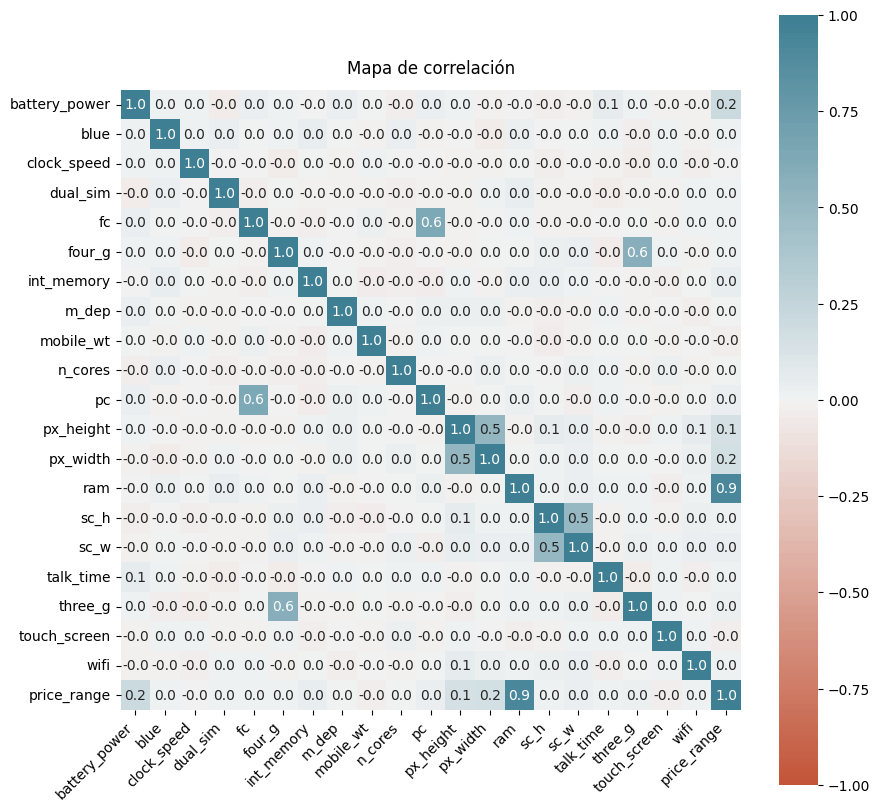

In [12]:
plt.figure(figsize=(10, 10))
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True, fmt=".1f"
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

ax.set_title('Mapa de correlación', fontdict={'fontsize':12}, pad=12);

## Variables catégoricas

### **1.2. Escriba el código para su análisis y la creación de gráficos de frecuencia:**



Frecuencia de blue:
blue
0    1010
1     990
Name: count, dtype: int64

Frecuencia de dual_sim:
dual_sim
1    1019
0     981
Name: count, dtype: int64

Frecuencia de four_g:
four_g
1    1043
0     957
Name: count, dtype: int64

Frecuencia de three_g:
three_g
1    1523
0     477
Name: count, dtype: int64

Frecuencia de touch_screen:
touch_screen
1    1006
0     994
Name: count, dtype: int64

Frecuencia de wifi:
wifi
1    1014
0     986
Name: count, dtype: int64


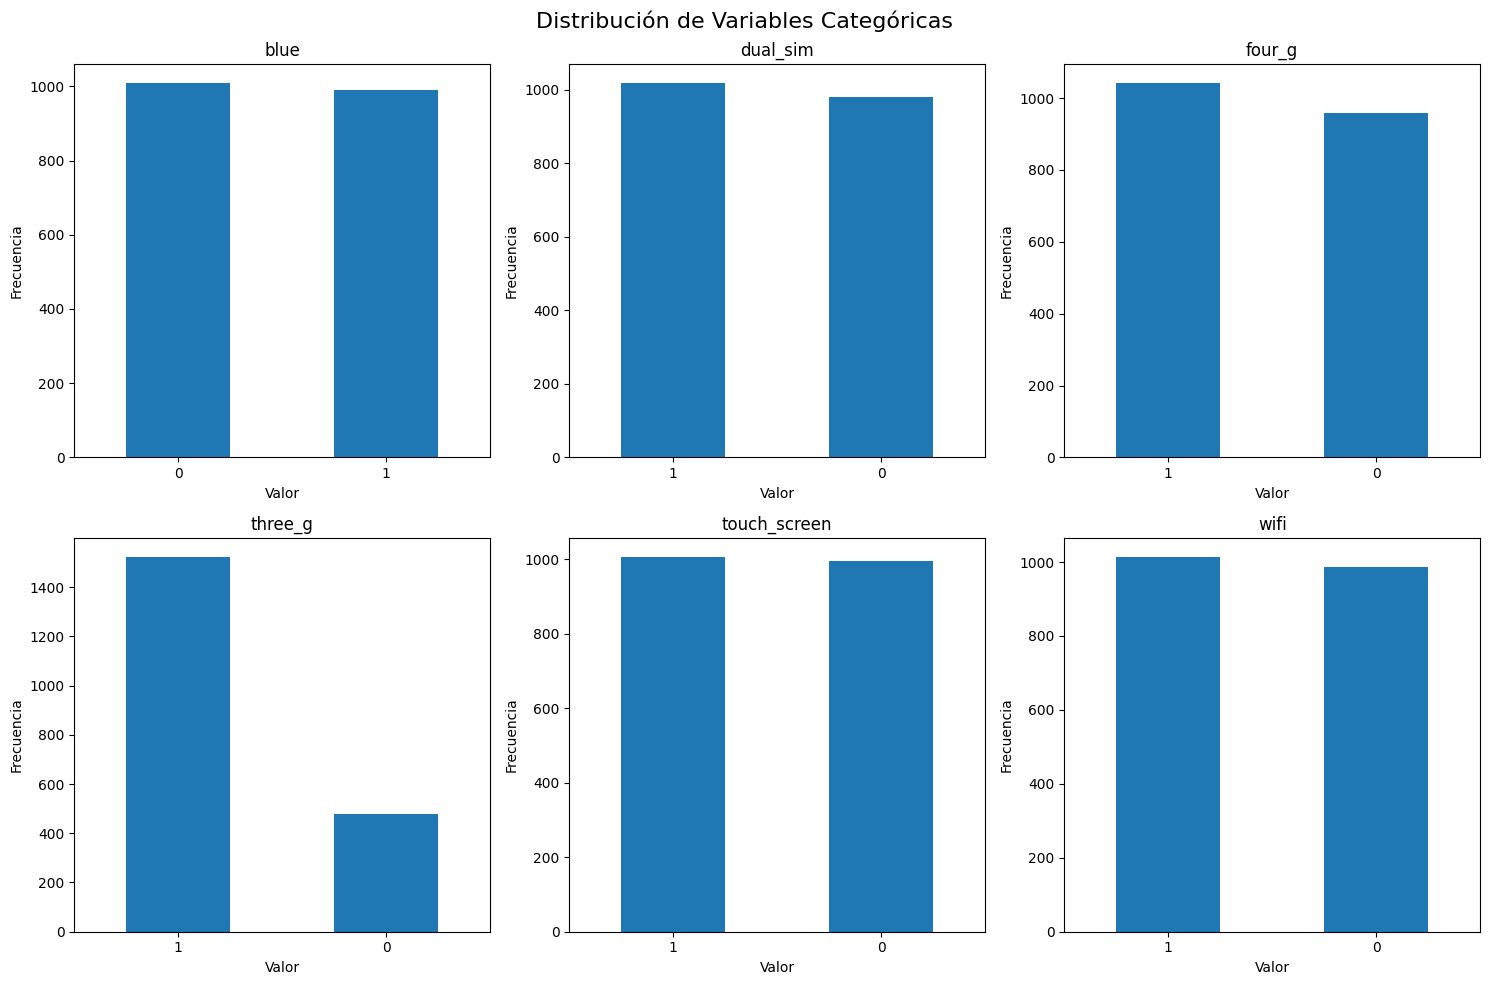

In [13]:
# Replaced plotting block with a dynamic-layout version
import math

# Análisis de frecuencias de cada variable categórica
for variable in categorical_variables:
    print(f"\nFrecuencia de {variable}:")
    print(data[variable].value_counts())

# Gráfico de frecuencia para cada variable categórica
n = len(categorical_variables)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
fig.suptitle('Distribución de Variables Categóricas', fontsize=16)

# axes can be 2D or 1D; flatten for uniform handling
axes_flat = axes.flatten() if hasattr(axes, "flatten") else np.array([axes])

for idx, variable in enumerate(categorical_variables):
    ax = axes_flat[idx]
    counts = data[variable].value_counts()
    counts.plot(kind='bar', ax=ax)
    ax.set_title(variable)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    labels = [str(x) for x in counts.index]
    ax.set_xticklabels(labels, rotation=0)

# hide any unused subplots
for ax in axes_flat[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


### **1.3. Escriba el código que permita validar si el dataset está balanceado**

             count  percent
price_range                
0              500     25.0
1              500     25.0
2              500     25.0
3              500     25.0


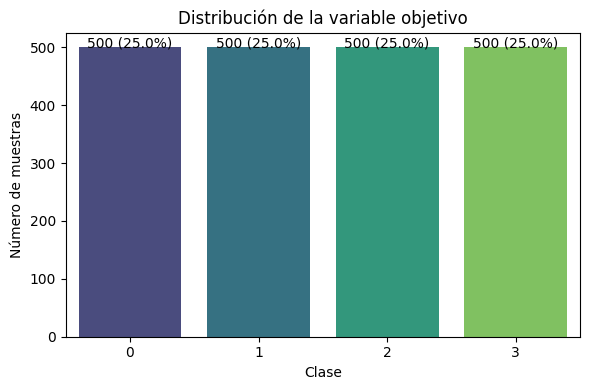

In [14]:
# sustituir 'price_range' por la columna objetivo
variable_objetivo = data['price_range']

# conteos y porcentajes
counts = variable_objetivo.value_counts().sort_index()
pct = (counts / counts.sum()) * 100
df_dist = pd.DataFrame({'count': counts, 'percent': pct})
print(df_dist)

# visualización
x_values = counts.index.astype(str)
y_values = counts.values

plt.figure(figsize=(6,4))
sns.barplot(x=x_values, y=y_values, palette='viridis', legend=False, hue=x_values)
plt.title('Distribución de la variable objetivo')
plt.xlabel('Clase')
plt.ylabel('Número de muestras')
for i,v in enumerate(counts.values):
    plt.text(i, v+0.5, f"{v} ({pct.iloc[i]:.1f}%)", ha='center')
plt.tight_layout()
plt.show()


## PREPROCESAMIENTO DE DATOS

In [15]:
#Crear una copia del dataset para modificaciones
data2 = data.copy()

In [16]:
#Verificar tamaño
data2.shape

(2000, 21)

### <font color="cyan">División de datos</font>

In [17]:
# Separación de los datos en train y test
X = data2.drop(columns = 'price_range')
y = data2['price_range']

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.8,
                                        random_state = seed,
                                        shuffle      = True
                                    )

### Escriba el código que permita reescalar todos los atributos del dataset utilizando la función del StandardScaler:

In [18]:
# Código para reescalar X_train y X_test mediante StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 2. Aplicación de SVM sobre los datos

⚠️ Importante:

A partir de esta sección, utiliza los datos estandarizados.

### **2.1. Escriba el código que permita crear un modelo utilizando SVM con kernel lineal, el valor de C =1 y random_state=seed**

In [19]:
# Creación del modelo SVM lineal
modeloSVM = SVC(C=1, kernel='linear', random_state=seed)
modeloSVM.fit(X_train, y_train)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [20]:
# Predicciones test
predictSVM = modeloSVM.predict(X_test)
predictSVM

array([1, 2, 2, 2, 2, 2, 1, 3, 1, 3, 3, 3, 0, 2, 3, 0, 3, 2, 2, 2, 0, 1,
       1, 0, 3, 2, 0, 3, 1, 0, 2, 0, 3, 3, 3, 3, 3, 3, 0, 2, 3, 1, 3, 2,
       1, 0, 2, 2, 0, 3, 3, 0, 1, 2, 1, 3, 3, 1, 2, 1, 1, 2, 2, 1, 2, 1,
       0, 3, 3, 3, 0, 3, 1, 3, 1, 2, 1, 2, 2, 3, 3, 2, 1, 0, 2, 3, 2, 3,
       3, 1, 1, 2, 0, 1, 3, 0, 1, 2, 2, 2, 0, 1, 0, 2, 3, 2, 3, 3, 1, 1,
       2, 2, 0, 1, 2, 3, 3, 2, 2, 1, 1, 0, 1, 2, 3, 1, 2, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 3, 1, 2, 0, 3, 3, 1, 1, 3, 0, 2, 0, 2, 0, 0, 3, 0, 3,
       1, 3, 2, 2, 1, 2, 2, 3, 0, 2, 2, 1, 1, 2, 0, 0, 1, 3, 1, 1, 3, 1,
       3, 0, 2, 2, 3, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 2, 2, 0, 1, 0,
       1, 1, 2, 3, 3, 0, 2, 1, 3, 3, 1, 3, 1, 0, 3, 1, 2, 3, 3, 2, 3, 3,
       3, 2, 0, 3, 0, 3, 1, 0, 2, 3, 0, 0, 2, 1, 3, 1, 3, 1, 1, 1, 3, 1,
       2, 0, 2, 2, 3, 2, 3, 1, 1, 3, 1, 3, 2, 0, 2, 1, 0, 2, 3, 1, 0, 0,
       0, 0, 1, 3, 2, 2, 1, 0, 3, 0, 0, 2, 3, 0, 3, 2, 1, 1, 3, 0, 0, 2,
       0, 0, 0, 1, 0, 2, 2, 1, 2, 0, 0, 0, 0, 3, 3,

### **2.2. Escriba el código que permita hallar la exactitud (accuracy) del modelo SVM anteriormente entrenado:**

In [21]:
accuracy_svm = accuracy_score(y_test, predictSVM)
print(f'Exactitud del modelo SVM: {accuracy_svm:.4f}')

Exactitud del modelo SVM: 0.9675


In [22]:
class_labels = ['Bajo', 'Medio', 'Alto', 'Muy Alto']
print(classification_report(y_test, predictSVM, target_names=class_labels))

              precision    recall  f1-score   support

        Bajo       0.98      0.99      0.98        93
       Medio       0.96      0.95      0.96       102
        Alto       0.96      0.94      0.95        98
    Muy Alto       0.97      0.99      0.98       107

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



### **2.3. Escriba el código que permita encontrar los mejores parámetros para el modelo  SVM, con un param_grid = {'C': np.linspace(0.1, 100, 20), 'kernel': ('linear', 'rbf')**

#### Ajuste de hiperparámetros (GridSearchCV)

⚠️ Restricción:

**No imprimas los resultados del GridSearchCV**. Solo utiliza los mejores parámetros encontrados.

In [23]:
# Para que no se impriman los resultados, estos se asignan a _
from sklearn.model_selection import GridSearchCV

# Parametros y los valores que van a tomar
param_grid = {'C': np.linspace(0.1, 100, 20),
              'kernel': ['linear', 'rbf']
             }

grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 0)

# fitting the model for grid search
# Para que no se impriman los resultados, estos se asignan a _
_ = grid.fit(X_train, y_train)

# Se asignan los resultados a un dataframe
resultados = pd.DataFrame(grid.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)')\
    .drop(columns = 'params')\
    .sort_values('mean_test_score', ascending = False) \
    .head(5)

,param_C,param_kernel,mean_test_score,std_test_score
16,42.163158,linear,0.969375,0.011075
18,47.421053,linear,0.969375,0.012087
14,36.905263,linear,0.969375,0.008705
10,26.389474,linear,0.968750,0.010643
22,57.936842,linear,0.968750,0.010643


### **2.4. Escriba el código que permita conocer los mejores parámetros encontrados en el ítem anterior**

In [24]:
# print best parameter after tuning
print(f'Mejores hiperparámetros {grid.best_params_}')


Mejores hiperparámetros {'C': np.float64(36.905263157894744), 'kernel': 'linear'}


### **2.5. Escriba el código que permita hallar la exactitud del modelo de SVM aplicando los mejores parámetros**

In [25]:
# Accuracy de test del modelo
# ==============================================================================

best_predictor = grid.best_estimator_
print(best_predictor.get_params())
best_prediction = best_predictor.predict(X_test)
accuracy_best = accuracy_score(y_test, best_prediction)
print(f'Exactitud del mejor modelo tras ajuste de hiperparámetros: {accuracy_best:.4f}')


{'C': np.float64(36.905263157894744), 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}
Exactitud del mejor modelo tras ajuste de hiperparámetros: 0.9650


### **2.6. Escriba el código que permita hallar la las métricas del modelo entrenado en el ítem anterior. Utilice la función classification_report**

In [26]:
from sklearn.metrics import classification_report
class_labels = ['Bajo', 'Medio', 'Alto', 'Muy Alto']
print(classification_report(y_test, predictSVM, target_names=class_labels))


              precision    recall  f1-score   support

        Bajo       0.98      0.99      0.98        93
       Medio       0.96      0.95      0.96       102
        Alto       0.96      0.94      0.95        98
    Muy Alto       0.97      0.99      0.98       107

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



# 3. REDES NEURONALES

⚠️ Recordatorio:

* Mantén los datos normalizados (los mismos que usaste en SVM).
* No regreses al dataset original ni repitas pasos anteriores, a menos que se indique explícitamente.

### **3.1. Escriba el código que permita entrenar un perceptrón multicapa con 3 capas ocultas con 200, 100 y 50 neuronas respectivamente en cada capa. Función de activación 'Relu' y random_state=seed**

In [27]:
from sklearn.neural_network import MLPClassifier

classifier = MLPClassifier(hidden_layer_sizes=(200, 100, 50), activation='relu', random_state=seed)
classifier.fit(X_train, y_train)

predictMLP = classifier.predict(X_test)
predictMLP

array([1, 2, 2, 2, 2, 2, 2, 3, 1, 3, 3, 3, 0, 2, 3, 0, 3, 2, 2, 2, 0, 1,
       1, 0, 3, 2, 0, 3, 1, 0, 2, 0, 3, 3, 3, 3, 3, 3, 0, 2, 3, 1, 3, 3,
       1, 0, 2, 2, 0, 3, 3, 0, 1, 2, 1, 3, 3, 1, 2, 1, 1, 2, 2, 1, 2, 1,
       0, 3, 3, 3, 0, 3, 1, 3, 1, 2, 1, 2, 2, 3, 3, 2, 1, 0, 2, 3, 2, 3,
       3, 2, 1, 2, 0, 1, 3, 0, 1, 2, 2, 2, 0, 1, 0, 2, 3, 2, 3, 2, 1, 1,
       1, 2, 0, 1, 2, 3, 3, 2, 2, 1, 1, 0, 1, 2, 3, 1, 2, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 3, 2, 2, 0, 3, 3, 1, 1, 3, 0, 2, 1, 2, 0, 0, 3, 0, 3,
       1, 3, 2, 2, 0, 2, 2, 3, 0, 2, 2, 1, 2, 2, 0, 0, 1, 3, 2, 1, 3, 1,
       3, 0, 2, 2, 3, 1, 1, 1, 0, 0, 2, 2, 0, 1, 0, 0, 0, 2, 2, 0, 1, 0,
       1, 1, 1, 2, 3, 0, 2, 1, 3, 3, 1, 3, 0, 0, 3, 1, 1, 3, 3, 2, 3, 3,
       3, 2, 0, 3, 0, 3, 1, 0, 2, 3, 0, 0, 2, 1, 3, 1, 3, 1, 2, 1, 2, 2,
       2, 0, 2, 2, 3, 2, 3, 0, 1, 3, 1, 3, 2, 0, 2, 2, 0, 1, 3, 1, 0, 0,
       0, 0, 1, 3, 2, 2, 1, 0, 3, 0, 0, 2, 3, 0, 3, 2, 1, 1, 3, 0, 0, 2,
       0, 0, 0, 1, 0, 2, 2, 1, 2, 0, 0, 0, 0, 3, 3,

### **3.2. Escriba el código que permita hallar la exactitud del modelo de redes neuronales anteriormente entrenado:**

Exactitud del modelo MLP: 0.9250


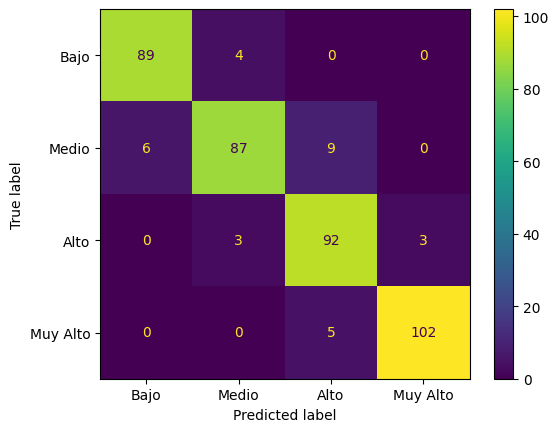

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

accuracy_mlp = accuracy_score(y_test, predictMLP)
print(f'Exactitud del modelo MLP: {accuracy_mlp:.4f}')

value_labels = [0, 1, 2, 3]

cm = confusion_matrix(y_test, predictMLP, labels=value_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot();

### **3.3. Escriba el código que permita hallar la las métricas del modelo entrenado en el ítem anterior. Utilice la función classification_report**

In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictMLP, target_names=class_labels))


              precision    recall  f1-score   support

        Bajo       0.94      0.96      0.95        93
       Medio       0.93      0.85      0.89       102
        Alto       0.87      0.94      0.90        98
    Muy Alto       0.97      0.95      0.96       107

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.92       400
weighted avg       0.93      0.93      0.92       400



### 4. **Conclusiones**

Escribe tus conclusiones finales, reflexionando sobre los resultados obtenidos con SVM y MLP. Compara los siguientes aspectos:

1. Métricas relevantes:

  * ¿Cuáles métricas fueron clave para evaluar el desempeño?

2. Fortalezas y limitaciones:

  * Ventajas y desventajas de cada modelo en este caso específico.

### <font color="cyan">Métricas relevantes</font>

* Para el modelo SVM se utilizó el ajuste de hiperpárametros (GridSearchVC) para la evaluación del usando hiperparámetro
* Para el modelo MLP se utilizó la matriz de confusión para la evaluación de falsos positivos / negativos
* Para ambos modelos se utilizaron las funciones `accuracy_score` y `classification_report`

### <font color="cyan">Fortalezas y limitaciones</font>

* Para ambos casos los modelos utilizados fueron para la evaluación de regresiones
* Para este caso los datos se encontraban balanceados
* En comparación el modelo SVM presentaba una mayor exactitud en contraste con el MLP

### <font color="cyan">Comentarios</font>

* Se observo una alta correlación directa entre la memoria RAM y el rango de precio

